## featureCounts 결과 불러오기

featureCounts가 생성한 chr17 유전자별 count 파일을 불러오고, 샘플 count 열의 이름을 `Count`로 정리한 뒤 처음 5개 행을 확인합니다.

In [3]:
from pathlib import Path
import pandas as pd

COUNT_FILE = Path(
    "../results/featurecounts_chr17/RNAseq_chr17_gene_counts.txt"
)

counts = pd.read_csv(
    COUNT_FILE,
    sep="\t",
    comment="#"
)

counts = counts.rename(
    columns={counts.columns[-1]: "Count"}
)

counts.head()

,Geneid,Chr,Start,End,Strand,Length,Count
0,ENSG00000280279,chr17;chr17;chr17;chr17;chr17,64099;65830;71366;75814;76723,65736;65887;71556;75878;76866,-;-;-;-;-,2096,24
1,ENSG00000280136,chr17;chr17;chr17;chr17;chr17;chr17;chr17;chr17,88641;97269;98893;101109;102058;105560;106755;...,88705;97797;98951;101174;102273;105691;106864;...,-;-;-;-;-;-;-;-,1373,15
2,ENSG00000277613,chr17,90796,90899,-,104,0
3,ENSG00000268320,chr17;chr17;chr17,137526;138203;138910,137645;138402;139067,+;+;+,478,0
4,ENSG00000272636,chr17;chr17;chr17;chr17;chr17;chr17;chr17;chr1...,142789;148173;149111;156019;156220;161415;1614...,147577;148269;149192;156377;156377;161541;1615...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-,6462,0


In [4]:
print("GTF에 등록된 전체 유전자:", len(counts))
print("Count가 1 이상인 유전자:", (counts["Count"] > 0).sum())
print("전체 assigned fragment:", counts["Count"].sum())

GTF에 등록된 전체 유전자: 3024
Count가 1 이상인 유전자: 1515
전체 assigned fragment: 1148261


## featureCounts 결과 탐색

단일 샘플이므로 차등발현 분석 대신, 검출된 유전자 비율과 count 분포 및 raw count 상위 유전자를 확인합니다.

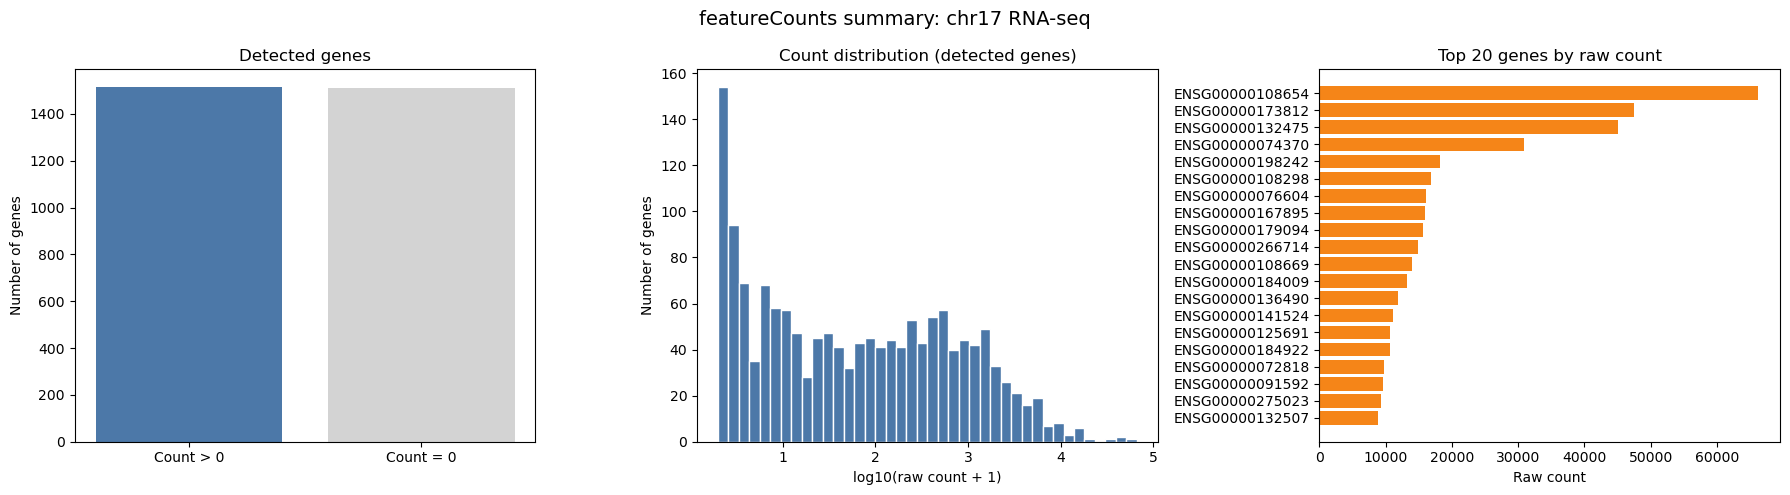

In [5]:
import numpy as np
import matplotlib.pyplot as plt

expressed = (counts["Count"] > 0).sum()
not_expressed = (counts["Count"] == 0).sum()
top20 = counts.nlargest(20, "Count").sort_values("Count")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(
    ["Count > 0", "Count = 0"],
    [expressed, not_expressed],
    color=["#4C78A8", "#D3D3D3"]
)
axes[0].set_title("Detected genes")
axes[0].set_ylabel("Number of genes")

axes[1].hist(
    np.log10(counts.loc[counts["Count"] > 0, "Count"] + 1),
    bins=40,
    color="#4C78A8",
    edgecolor="white"
)
axes[1].set_title("Count distribution (detected genes)")
axes[1].set_xlabel("log10(raw count + 1)")
axes[1].set_ylabel("Number of genes")

axes[2].barh(top20["Geneid"], top20["Count"], color="#F58518")
axes[2].set_title("Top 20 genes by raw count")
axes[2].set_xlabel("Raw count")

fig.suptitle("featureCounts summary: chr17 RNA-seq", fontsize=14)
fig.tight_layout()
plt.show()


> **해석 주의:** 위 상위 유전자 그래프는 raw count 기준입니다. 유전자 길이와 sequencing depth의 영향을 받으므로, 서로 다른 유전자의 실제 발현량을 엄밀히 비교하려면 다음 단계에서 TPM 등의 정규화가 필요합니다.

## 유전자 길이를 보정한 TPM 계산

TPM(Transcripts Per Million)은 먼저 `Count / Length(kb)`로 RPK를 계산하고, 모든 RPK의 합이 1,000,000이 되도록 보정합니다.

- `Length_kb = Length / 1,000`
- `RPK = Count / Length_kb`
- `TPM = RPK / sum(RPK) × 1,000,000`

TPM 합계: 1,000,000.00


,Geneid,Length,Count,TPM
0,ENSG00000173812,3623,47494,51464.057113
1,ENSG00000108298,1761,16844,37550.825023
2,ENSG00000108654,7388,66210,35182.792552
3,ENSG00000198242,2232,18213,32034.717892
4,ENSG00000132475,6134,45141,28890.895973
5,ENSG00000074370,6893,30945,17624.459821
6,ENSG00000184009,2993,13253,17383.654733
7,ENSG00000279602,1321,5202,15459.702658
8,ENSG00000189343,883,3234,14378.478040
9,ENSG00000076604,4573,16090,13813.013911


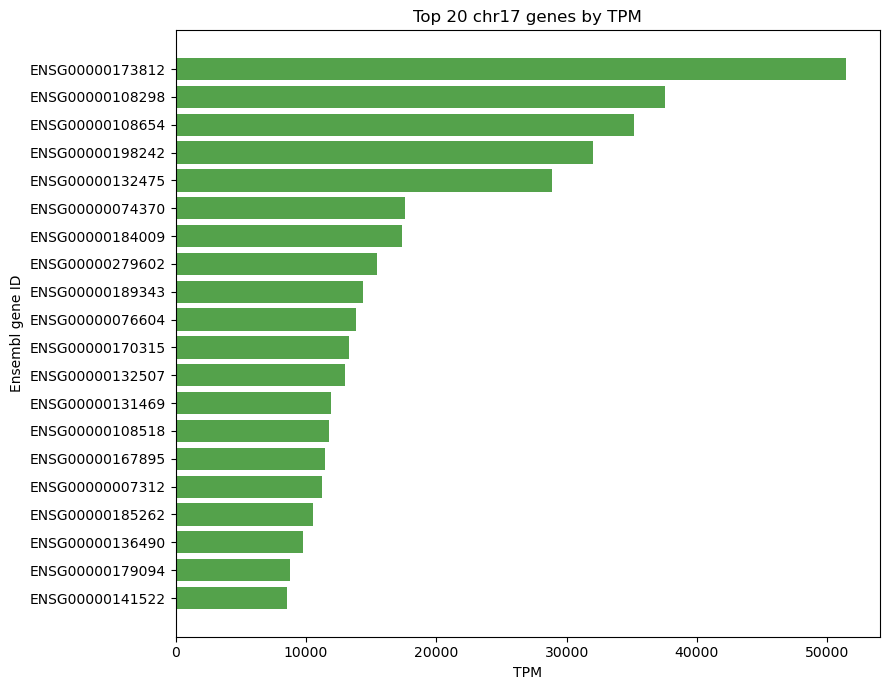

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 이 셀만 실행해도 되도록 featureCounts 결과를 다시 불러옵니다.
COUNT_FILE = Path("../results/featurecounts_chr17/RNAseq_chr17_gene_counts.txt")
counts = pd.read_csv(COUNT_FILE, sep="\t", comment="#")
counts = counts.rename(columns={counts.columns[-1]: "Count"})

# 1. 유전자 길이를 bp에서 kb로 변환합니다.
counts["Length_kb"] = counts["Length"] / 1_000

# 2. 유전자 길이를 보정한 RPK를 계산합니다.
counts["RPK"] = counts["Count"] / counts["Length_kb"]

# 3. 전체 RPK 합이 1,000,000이 되도록 TPM을 계산합니다.
counts["TPM"] = counts["RPK"] / counts["RPK"].sum() * 1_000_000

# 계산 확인: TPM의 합은 약 1,000,000이어야 합니다.
assert np.isclose(counts["TPM"].sum(), 1_000_000)
print(f"TPM 합계: {counts['TPM'].sum():,.2f}")

# TPM 기준 상위 20개 유전자를 표와 그래프로 확인합니다.
top20_tpm = counts.nlargest(20, "TPM")
display(top20_tpm[["Geneid", "Length", "Count", "TPM"]].reset_index(drop=True))

plot_data = top20_tpm.sort_values("TPM")
plt.figure(figsize=(9, 7))
plt.barh(plot_data["Geneid"], plot_data["TPM"], color="#54A24B")
plt.title("Top 20 chr17 genes by TPM")
plt.xlabel("TPM")
plt.ylabel("Ensembl gene ID")
plt.tight_layout()
plt.show()


## chr17 위치에 따른 유전자 발현 분포

각 유전자의 chr17 중간 위치를 x축에, `log10(TPM + 1)`을 y축에 표시합니다. 회색 점은 TPM이 0인 유전자이고 파란 점은 검출된 유전자입니다. TPM 상위 10개에는 GTF에서 가져온 gene symbol을 표시합니다.

In [ ]:
import re

GTF_FILE = Path(
    "/mnt/HDD3/class_2025_2/BI_sample_datasets/RefGenome/"
    "Homo_sapiens_assembly38_chr17.gtf"
)

# featureCounts의 exon 좌표들에서 유전자 전체 시작과 끝을 구합니다.
counts["Gene_start"] = counts["Start"].astype(str).str.split(";").apply(
    lambda positions: min(map(int, positions))
)
counts["Gene_end"] = counts["End"].astype(str).str.split(";").apply(
    lambda positions: max(map(int, positions))
)
counts["Position_Mb"] = (counts["Gene_start"] + counts["Gene_end"]) / 2 / 1_000_000
counts["log10_TPM_plus_1"] = np.log10(counts["TPM"] + 1)

# GTF의 Ensembl gene ID와 읽기 쉬운 gene symbol을 연결합니다.
gene_symbols = {}
with GTF_FILE.open() as gtf:
    for line in gtf:
        if line.startswith("#"):
            continue
        fields = line.rstrip().split("\t")
        if len(fields) != 9 or fields[2] != "gene":
            continue
        gene_id = re.search(r'gene_id "([^"]+)"', fields[8])
        gene_name = re.search(r'gene_name "([^"]+)"', fields[8])
        if gene_id and gene_name:
            gene_symbols[gene_id.group(1)] = gene_name.group(1)

counts["Gene_symbol"] = counts["Geneid"].map(gene_symbols).fillna(counts["Geneid"])

detected = counts["TPM"] > 0
top10_tpm = counts.nlargest(10, "TPM")

plt.figure(figsize=(15, 6))
plt.scatter(
    counts.loc[~detected, "Position_Mb"],
    counts.loc[~detected, "log10_TPM_plus_1"],
    s=10, alpha=0.35, color="#BDBDBD", label="TPM = 0"
)
plt.scatter(
    counts.loc[detected, "Position_Mb"],
    counts.loc[detected, "log10_TPM_plus_1"],
    s=14, alpha=0.55, color="#4C78A8", label="TPM > 0"
)

for _, gene in top10_tpm.iterrows():
    plt.annotate(
        gene["Gene_symbol"],
        (gene["Position_Mb"], gene["log10_TPM_plus_1"]),
        xytext=(4, 5), textcoords="offset points", fontsize=9
    )

plt.title("Gene expression across chromosome 17")
plt.xlabel("Genomic position on chr17 (Mb)")
plt.ylabel("log10(TPM + 1)")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()
